<img style="float:left" width="70%" src="pics/escudo_COLOR_1L_DCHA.png">
<img style="float:right" width="15%" src="pics/PythonLogo.svg">
<br style="clear:both;">

<style>
@import url("https://cdnjs.cloudflare.com/ajax/libs/font-awesome/4.7.0/css/font-awesome.min.css");
</style>

# Minería de datos

<h2 style="display: inline-block; padding: 4mm; padding-left: 2em; background-color: navy; line-height: 1.3em; color: white; border-radius: 10px;">Práctica 1</h2>
 
## Estudiantes (1-2)

- Rubén Moreno
- Lucía Toimil

## Descripción de los datos

Se trabajará con el conjunto de datos **Maternal Health Risk**, disponible en https://archive.ics.uci.edu/dataset/863/maternal%2Bhealth%2Brisk

Este conjunto de datos real recoge indicadores biométricos (edad, presión arterial, glucosa, etc.) de mujeres embarazadas para predecir su nivel de riesgo (*RiskLevel*).

Se presenta el conjunto en el siguiente artículo:
> Ahmed, Marzia, et al. "[Review and analysis of risk factor of maternal health in remote area using the Internet of Things (IoT).](https://www.semanticscholar.org/paper/f175092a3b2217c9abca5bf5d91bab3c245c6b10)" InECCE2019: Proceedings of the 5th International Conference on Electrical, Control & Computer Engineering, Kuantan, Pahang, Malaysia, 29th July 2019. Singapore: Springer Singapore, 2020.

Tiene 6 atributos numéricos: *Age*, *SystolicBP*, *DiastolicBP*, *BS*, *BodyTemp*, *HeartRate*.

Hay tres niveles de riesgo: *low risk, mid risk, high risk*.

 <a id="index"></a>
## Tareas

1. [Carga de datos y verificación inicial.](#T1)
2. [Distribuciones y duplicados.](#T2)
3. [Análisis por clase y correlaciones.](#T3)
4. [Atributos derivados.](#T4)
5. [Agrupaciones.](#T5)
6. [Primeros modelos con scikit-learn.](#T6)
7. [Uso de atributos calculado.](#T7)
8. [Validación cruzada.](#T8)
9. [Efecto de los duplicados.](#T9)
10. [Análisis libre.](#T10)


  
 Para cada tarea responde después de su descripción con celdas de código y/o texto. Separa claramente los apartados de cada tarea.

<a id="T1"></a>
##  Tarea 1. Carga de datos y verificación inicial. <a href="#index"><i class="fa fa-list-alt" aria-hidden="true"></i></a>

1. Carga el conjunto en un dataframe.
1. Muestra:
   - una vista de las 10 primeras filas,
   - el tamaño del conjunto (filas y columnas),
   - los nombres de las columnas,
   - un resumen de tipos de datos y valores no nulos por columna,
   - una tabla de estadísticos descriptivos de las variables numéricas.
1. Escribe (en una celda de texto):
   - Nº filas y columnas.
   - Nombre de la variable objetivo y valores posibles.
   - Si hay valores ausentes y dónde.
   - Una variable con un rango (min–max) “curioso” y por qué.

## IMPORTS

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Carga en un dataframe

In [69]:
archivo=pd.read_csv("Maternal Health Risk Data Set.csv")

## Mostrar  Elementos

In [70]:
print("\n10 primeras filas del archivo:\n")
print(archivo.head(10))
print("\nDimensiones del archivo:\n")
print(archivo.shape)
print("\nnombres de las columnas:\n")
print(archivo.columns)
print("\ninformación del archivo:\n")
print(archivo.info())
print("\nestadísticas descriptivas:\n")
print(archivo.describe())


10 primeras filas del archivo:

   Age  SystolicBP  DiastolicBP     BS  BodyTemp  HeartRate  RiskLevel
0   25         130           80  15.00      98.0         86  high risk
1   35         140           90  13.00      98.0         70  high risk
2   29          90           70   8.00     100.0         80  high risk
3   30         140           85   7.00      98.0         70  high risk
4   35         120           60   6.10      98.0         76   low risk
5   23         140           80   7.01      98.0         70  high risk
6   23         130           70   7.01      98.0         78   mid risk
7   35          85           60  11.00     102.0         86  high risk
8   32         120           90   6.90      98.0         70   mid risk
9   42         130           80  18.00      98.0         70  high risk

Dimensiones del archivo:

(1014, 7)

nombres de las columnas:

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel'],
      dtype='object')

info

## Información del Dataset

- Tiene un total de **1014 filas** y **7 columnas**.

## Variable objetivo

La variable objetivo es **_RiskLevel_** y puede ser:

- **High risk**
- **Low risk**
- **Mid risk**

## Valores ausentes

No hay valores ausentes, podemos ver que en la información del archivo en todas las columnas nos salen **1014 no nulos**.

## Observación sobre los datos

Un dato que llama la atención en su mínimo principalmente es el de **heart rate**, ya que el mínimo es de **7** y es un dato incompatible con la vida, por lo que es posible que esté mal.

<a id="T2"></a>
##  Tarea 2. Distribuciones y duplicados. <a href="#index"><i class="fa fa-list-alt" aria-hidden="true"></i></a>
1. Distribución de la clase. Muestra cuántos ejemplos hay de cada valor de RiskLevel y represéntalo con un gráfico sencillo.
1. Comprueba si existen filas duplicadas (filas exactamente iguales en todas sus columnas).
   * Indica cuántas filas duplicadas hay.
   * Muestra 3 ejemplos distintos de filas duplicadas (tres patrones diferentes, no la misma fila repetida).
1. Calcula cuántas veces aparece cada fila distinta (considerando todas las columnas).
   * Muestra las 10 filas más repetidas con su número de repeticiones.
   * Dibuja un gráfico de barras con esas 10 repeticiones.
   * Indica cuántas filas distintas aparecen una sola vez, cuántas aparecen 2 veces, 3 veces, etc. (distribución de frecuencias).
1. Duplicados por clase. Para cada valor de RiskLevel, calcula el número de ejemplos totales y el porcentaje de filas duplicadas dentro de esa clase. Represéntalo con un gráfico de barras.
1. Comprueba si existen filas con los mismos valores en todas las variables de entrada pero con distinto RiskLevel.
   * Indica cuántos “patrones de entrada” presentan conflicto.
   * Si existe alguno, muestra hasta 5 ejemplos (las filas implicadas).

##  Cuántos ejemplos hay de cada valor de RiskLevel y su representacion grafica

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


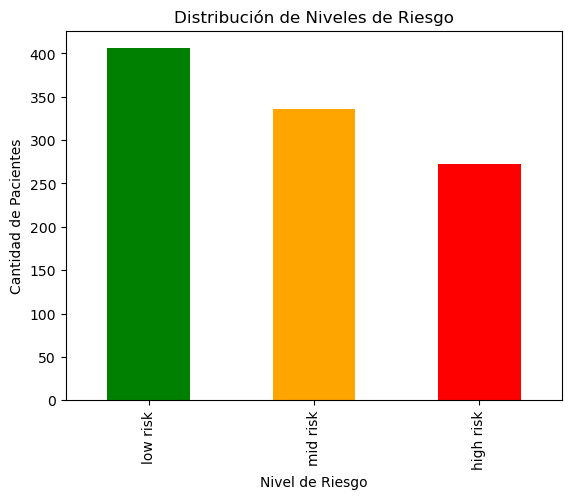

In [71]:
conteo=archivo['RiskLevel'].value_counts()
print(conteo)
conteo.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Distribución de Niveles de Riesgo')
plt.xlabel('Nivel de Riesgo')
plt.ylabel('Cantidad de Pacientes')
plt.show()

## Filas duplicadas 

In [72]:
duplicadas = archivo[archivo.duplicated()]
print("\nNúmero de filas duplicadas:", len(duplicadas))
ejemplos= archivo[archivo.duplicated()].head(10)
print("\nEjemplos de filas duplicadas:\n", ejemplos)



Número de filas duplicadas: 562

Ejemplos de filas duplicadas:
      Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
67    19         120           80   7.0      98.0         70   mid risk
72    19         120           80   7.0      98.0         70   mid risk
97    19         120           80   7.0      98.0         70   mid risk
106   50         140           90  15.0      98.0         90  high risk
107   25         140          100   6.8      98.0         80  high risk
118   32         140          100   7.9      98.0         78  high risk
119   30         140          100  15.0      98.0         70  high risk
129   48         120           80  11.0      98.0         88  high risk
130   40         160          100  19.0      98.0         77  high risk
131   32         140           90  18.0      98.0         88  high risk


## Filas distintas

Age  SystolicBP  DiastolicBP  BS    BodyTemp  HeartRate  RiskLevel
19   120         80           7.0   98.0      70         mid risk     27
48   120         80           11.0  98.0      88         high risk    14
31   120         60           6.1   98.0      76         mid risk     13
40   160         100          19.0  98.0      77         high risk    10
55   140         95           19.0  98.0      77         high risk    10
32   140         90           18.0  98.0      88         high risk     9
54   140         100          15.0  98.0      66         high risk     9
40   120         95           11.0  98.0      80         high risk     7
42   120         80           7.5   98.0      70         low risk      7
32   120         90           7.5   98.0      70         low risk      7
Name: count, dtype: int64


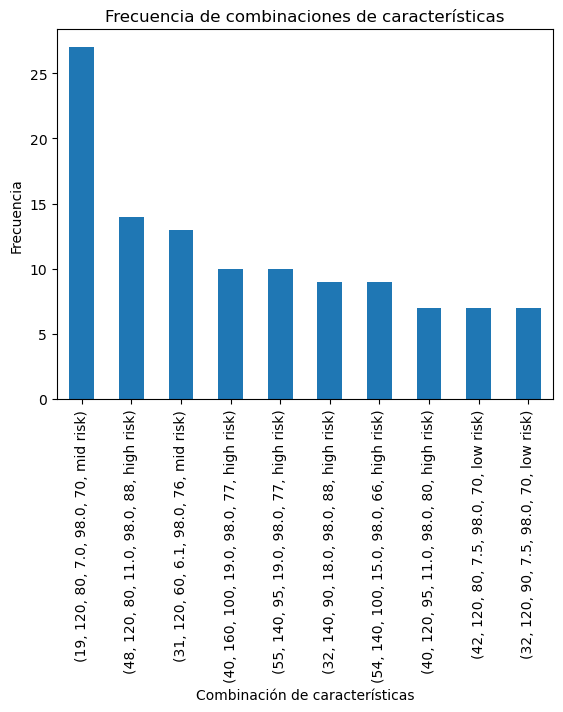


Distribución de frecuencias de combinaciones de características:

count
1     148
2     198
3      54
4      24
5      11
6       5
7       5
9       2
10      2
13      1
14      1
27      1
Name: count, dtype: int64


In [73]:
frec = archivo.value_counts()
print(frec.head(10))
frec.head(10).plot(kind='bar')
plt.title('Frecuencia de combinaciones de características')
plt.xlabel('Combinación de características')
plt.ylabel('Frecuencia')
plt.show()

print("\nDistribución de frecuencias de combinaciones de características:\n")
distribucion = frec.value_counts().sort_index()
print(distribucion)

## Duplicados por clase

In [74]:
dups={}
resumen={}
for indice, fila in archivo.iterrows():
    valor = fila['RiskLevel']
    if valor in resumen:
        resumen[valor]['count'] += 1
    else:
        resumen[valor] = {'count': 1, 'duplidados': 0}
    if valor in dups:
        for item in dups[valor]:
            if item == fila.drop('RiskLevel').tolist():
                resumen[valor]['duplidados'] += 1
                break
        dups[valor].append(fila.drop('RiskLevel').tolist())  
    else:
        dups[valor] = [fila.drop('RiskLevel').tolist()]
        
print("\nResumen de frecuencias y duplicados por nivel de riesgo:\n")
print(resumen)



Resumen de frecuencias y duplicados por nivel de riesgo:

{'high risk': {'count': 272, 'duplidados': 160}, 'low risk': {'count': 406, 'duplidados': 172}, 'mid risk': {'count': 336, 'duplidados': 230}}


## Filas conflicto

In [75]:
variables_entrada = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
#aqui miramos si para un conjunto de valores hay varios risk levels, si estuviese todo bien, el conteo de unicos deberia ser 1 para cada combinacion de valores
conflictosProv = archivo.groupby(variables_entrada)['RiskLevel'].nunique()
conflictos= conflictosProv[conflictosProv > 1]
total_conflictos = len(conflictos)
print(f"Hay un total de {total_conflictos} patrones que generan conflicto")

if total_conflictos > 0:
    print("\nEjemplos de patrones con conflicto:\n")
    print(conflictos.head(5))
else:
    print("No hay patrones con conflictos")


Hay un total de 35 patrones que generan conflicto

Ejemplos de patrones con conflicto:

Age  SystolicBP  DiastolicBP  BS   BodyTemp  HeartRate
12   90          60           7.5  102.0     66           2
     95          60           6.9  98.0      65           2
13   90          65           7.5  101.0     80           2
15   120         80           7.5  98.0      70           2
16   100         70           6.9  98.0      80           2
Name: RiskLevel, dtype: int64


<a id="T3"></a>
##  Tarea 3. Análisis por clase y correlaciones. <a href="#index"><i class="fa fa-list-alt" aria-hidden="true"></i></a>
1. Resumen por clase. Calcula, para cada RiskLevel, la media y mediana de cada atributo. Construye y muestra una tabla con esa información.
   - ¿Para qué atributos la media y/o la mediana muestran un aumento o disminución claro al pasar de ```low``` -> ```mid``` -> ```high```?
   - Si tuvieras que quedarte con 3 atributos para una primera versión del modelo, ¿cuáles elegirías basándote solo en esta tabla?
2. Para los 3 atributos elegidos en el apartado anterior, representa su distribución separando por RiskLevel con algún gráfico adecuado.
3. Relación entre variables (correlación + 2 pares)
   - Calcula y muestra la matriz de correlación de las variables numéricas.
   - Identifica 1 par con correlación alta (en valor absoluto) y 1 par con correlación baja/moderada.
   - Dibuja 2 scatter plots (uno por par). Opcionalmente, colorea por RiskLevel.


## Mediana y media de cada atributo para cada risk level

In [76]:
atbPorNivel = archivo.groupby('RiskLevel')
atbPorNivelMedia = atbPorNivel[variables_entrada].mean()
atbPorNivelMediana = atbPorNivel[variables_entrada].median()
print("\nAtributos por nivel de riesgo (mediana):\n")
print(atbPorNivelMediana)
print("\nAtributos por nivel de riesgo (media):\n")
print(atbPorNivelMedia)



Atributos por nivel de riesgo (mediana):

            Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate
RiskLevel                                                          
high risk  35.0       130.0         90.0  11.0      98.0       77.0
low risk   22.0       120.0         75.0   7.5      98.0       70.0
mid risk   25.0       120.0         75.0   7.0      98.0       76.0

Atributos por nivel de riesgo (media):

                 Age  SystolicBP  DiastolicBP         BS   BodyTemp  HeartRate
RiskLevel                                                                     
high risk  36.216912  124.194853    85.073529  12.122610  98.899265  76.742647
low risk   26.869458  105.866995    72.534483   7.220271  98.368966  72.770936
mid risk   28.363095  113.154762    74.232143   7.795744  98.833333  74.175595



### Atributos que muestran diferencias entre niveles de riesgo

Los atributos que muestran diferencias entre los diferentes niveles de riesgo son la edad, las presiones sistolica y diastolica, la BS y la valocidad del corazón. En la temperatura corporal no se observan diferencias.

---

### Selección de atributos para una primera versión del modelo

Si tuviese que escoger solo 3 atributos para una primera version del modelo, me quedaria con la edad y las presiones sistolica y diastolica, pues hay diferentecias claras y coherentes entre los valores para los diferentes niveles de riesgo.

## Distribucion de los atrubutos seleccionados

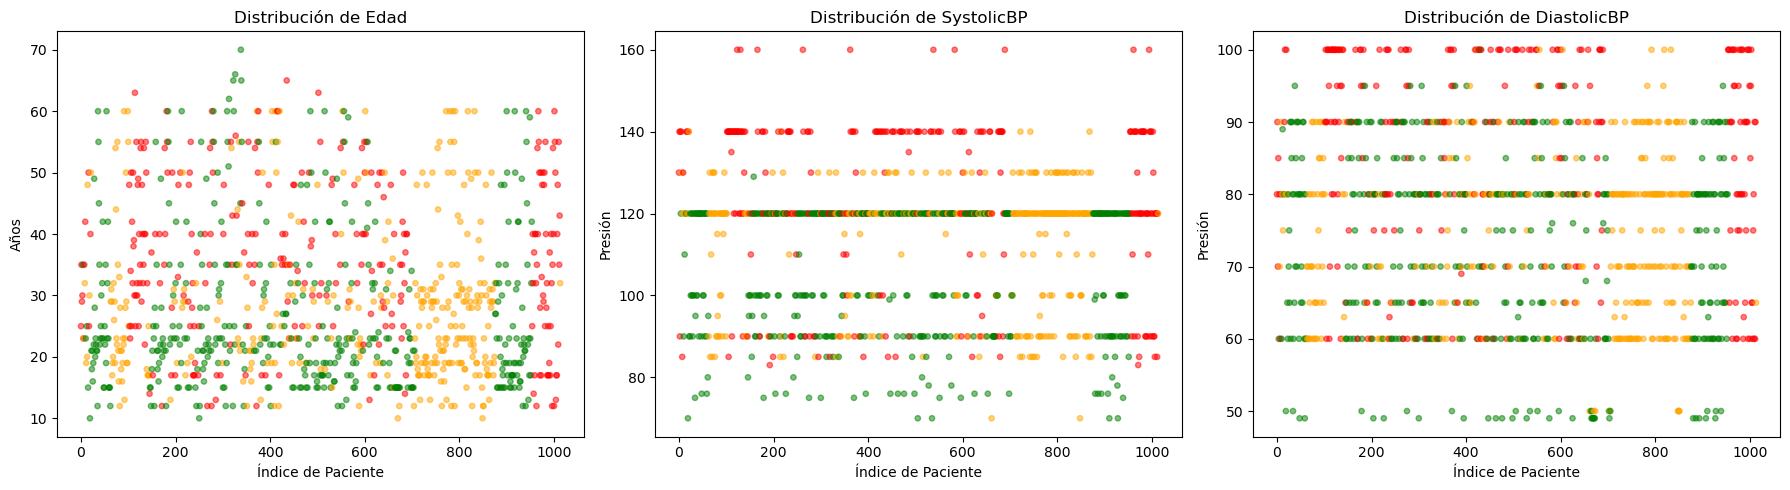

In [77]:
coloresDict = {'low risk': 'green', 'mid risk': 'orange', 'high risk': 'red'}
colores = archivo['RiskLevel'].map(coloresDict)

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.scatter(archivo.index, archivo['Age'], c=colores, s=15, alpha=0.5)
plt.title('Distribución de Edad')
plt.ylabel('Años')
plt.xlabel('Índice de Paciente')

plt.subplot(1, 3, 2)
plt.scatter(archivo.index, archivo['SystolicBP'], c=colores, s=15, alpha=0.5)
plt.title('Distribución de SystolicBP')
plt.ylabel('Presión')
plt.xlabel('Índice de Paciente')

plt.subplot(1, 3, 3)
plt.scatter(archivo.index, archivo['DiastolicBP'], c=colores, s=15, alpha=0.5)
plt.title('Distribución de DiastolicBP')
plt.ylabel('Presión')
plt.xlabel('Índice de Paciente')

plt.tight_layout()
plt.show()

## Relación entre variables

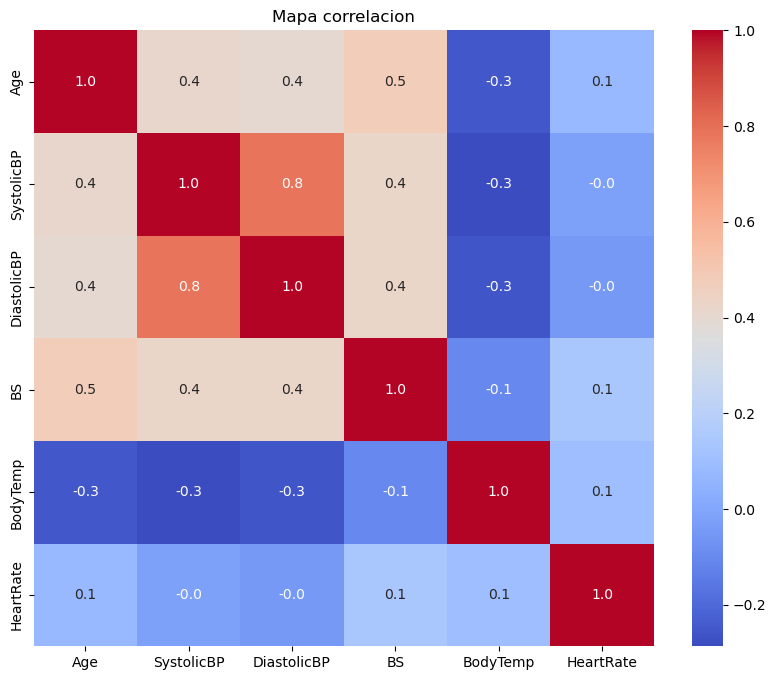

In [78]:
plt.figure(figsize=(10,8))
corr=archivo.drop("RiskLevel", axis=1).corr()
sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Mapa correlacion")
plt.show()

Podemos ver que con un 0,8 la presion sistolica y diastolica estan muy relacionada.
Por otro lado la relacion entre la edad y la presion diastolica es mucho mas moderada.

Text(0, 0.5, 'Presión Diastólica (mmHg)')

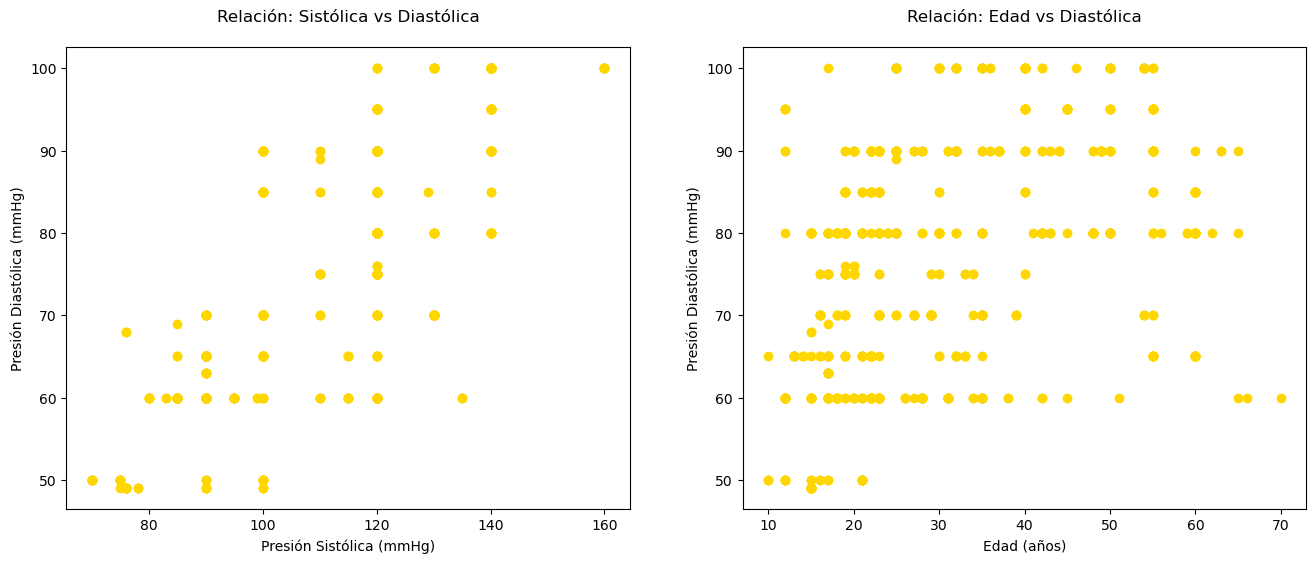

In [79]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.scatter(archivo['SystolicBP'], archivo['DiastolicBP'], c='gold')   
plt.title('Relación: Sistólica vs Diastólica\n')
plt.xlabel('Presión Sistólica (mmHg)')
plt.ylabel('Presión Diastólica (mmHg)')

plt.subplot(1, 2, 2)
plt.scatter(archivo['Age'], archivo['DiastolicBP'], c='gold')
plt.title('Relación: Edad vs Diastólica\n')
plt.xlabel('Edad (años)')
plt.ylabel('Presión Diastólica (mmHg)')

<a id="T4"></a>
##  Tarea 4. Atributos derivados. <a href="#index"><i class="fa fa-list-alt" aria-hidden="true"></i></a>
1. Crea nuevas variables (atributos).
   - PulsePressure = SystolicBP - DiastolicBP
   - MAP = (SystolicBP + 2*DiastolicBP) / 3 (*estimación clásica*)
   - AgeGroup: discretiza Age en 4 tramos (a tu elección, pero razonables)
1. Resumen por clase de las nuevas variables
   - Para las nuevas variables numérica, calcula media y mediana por RiskLevel y muéstralo en una tabla.
   - Para AgeGroup, muestra una tabla de frecuencias por RiskLevel (en conteos o porcentajes).
1. Visualización
   - Para cada nueva variable, representa su distribución por RiskLevel con un gráfico adecuado.

## Creacion de nuevas variables

In [80]:
archivo['PulsePressure'] = archivo['SystolicBP'] - archivo['DiastolicBP']
archivo['MAP'] = (archivo['SystolicBP'] + 2 * archivo['DiastolicBP']) / 3
archivo["Age Group"] = pd.cut(archivo["Age"], bins=[0, 20, 35, 60, 100], labels=["0-20", "21-35", "36-60", "61+"])

## Resumen de las nuevas variables

In [81]:
mediaNueva= archivo.groupby('RiskLevel')[['PulsePressure', 'MAP']].mean()
medianaNueva= archivo.groupby('RiskLevel')[['PulsePressure', 'MAP']].median()
print("\nAtributos por nivel de riesgo (media):\n")
print(mediaNueva)
print("\nAtributos por nivel de riesgo (mediana):\n")
print(medianaNueva)

frecuenciasAgeGroups = pd.crosstab(archivo['Age Group'], archivo['RiskLevel'])
print("\nFrecuencias de grupos de edad por nivel de riesgo:\n")
print(frecuenciasAgeGroups)


Atributos por nivel de riesgo (media):

           PulsePressure        MAP
RiskLevel                          
high risk      39.121324  98.113971
low risk       33.332512  83.645320
mid risk       38.922619  87.206349

Atributos por nivel de riesgo (mediana):

           PulsePressure    MAP
RiskLevel                      
high risk           40.0  100.0
low risk            30.0   90.0
mid risk            40.0   90.0

Frecuencias de grupos de edad por nivel de riesgo:

RiskLevel  high risk  low risk  mid risk
Age Group                               
0-20              39       150       112
21-35            101       184       160
36-60            129        67        64
61+                3         5         0


## Representacion en graficas

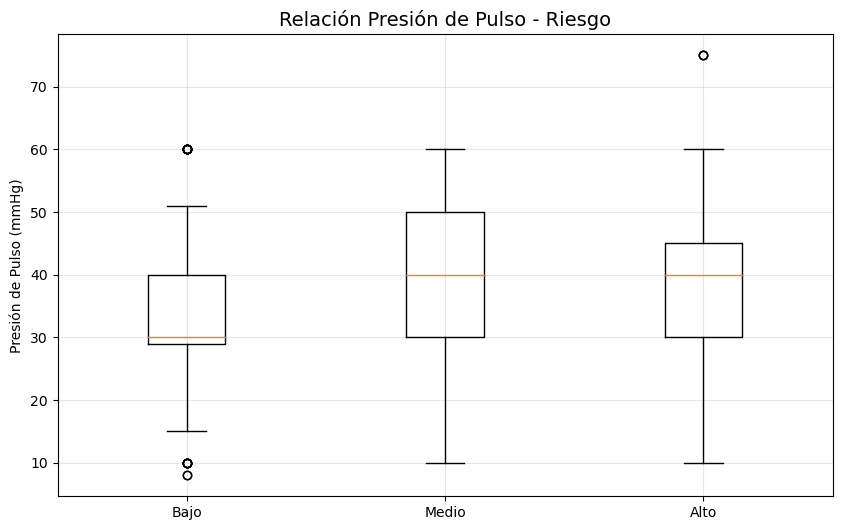

In [82]:
plt.figure(figsize=(10,6))

bajo = archivo[archivo["RiskLevel"] == "low risk"]["PulsePressure"]
medio = archivo[archivo["RiskLevel"] == "mid risk"]["PulsePressure"]
alto = archivo[archivo["RiskLevel"] == "high risk"]["PulsePressure"]

plt.boxplot([bajo, medio, alto], labels=["Bajo", "Medio", "Alto"])
plt.title("Relación Presión de Pulso - Riesgo", fontsize=14)
plt.ylabel("Presión de Pulso (mmHg)")
plt.grid(True, alpha=0.3)
plt.show()

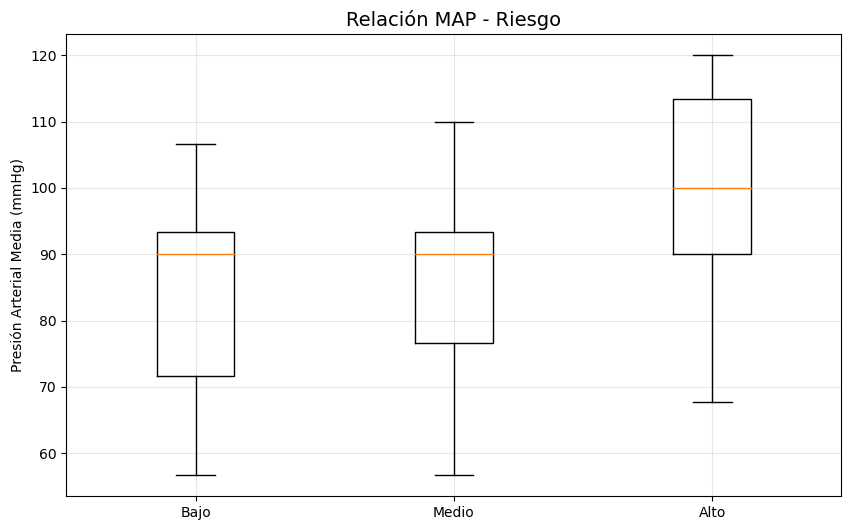

In [83]:
plt.figure(figsize=(10,6))

bajo = archivo[archivo["RiskLevel"] == "low risk"]["MAP"]
medio = archivo[archivo["RiskLevel"] == "mid risk"]["MAP"]
alto = archivo[archivo["RiskLevel"] == "high risk"]["MAP"]

plt.boxplot([bajo, medio, alto], labels=["Bajo", "Medio", "Alto"])
plt.title("Relación MAP - Riesgo", fontsize=14)
plt.ylabel("Presión Arterial Media (mmHg)")
plt.grid(True, alpha=0.3)
plt.show()

Text(0, 0.5, 'Cantidad de Pacientes')

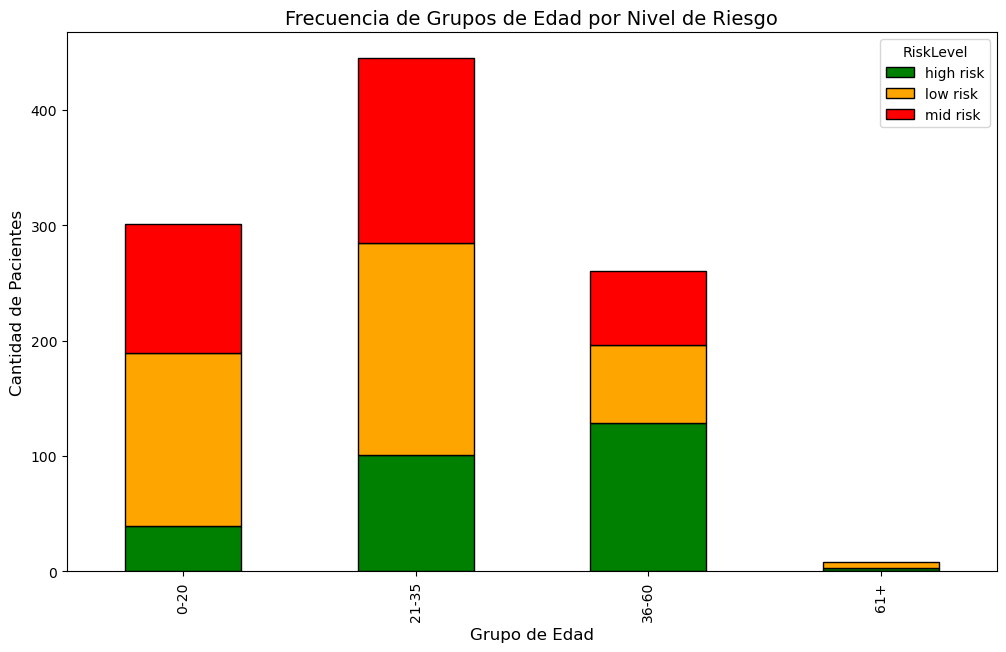

In [84]:
frecuenciasAgeGroups = pd.crosstab(archivo['Age Group'], archivo['RiskLevel'])
ax = frecuenciasAgeGroups.plot(kind='bar', stacked=True, figsize=(12, 7), color=['green', 'orange', 'red'], edgecolor='black')
plt.title('Frecuencia de Grupos de Edad por Nivel de Riesgo', fontsize=14)
plt.xlabel('Grupo de Edad', fontsize=12)
plt.ylabel('Cantidad de Pacientes', fontsize=12)

#preguntar si es esto o esto es lo primero que se pide en el ejercicio 5



<a id="T5"></a>
##  Tarea 5. Agrupaciones. <a href="#index"><i class="fa fa-list-alt" aria-hidden="true"></i></a>
1. Matriz de co-ocurrencia.
   - Crea una tabla que cruce ```AgeGroup``` con ```RiskLevel```.
   - Muestra esos valores en un gráfico de barras.
1. Resumen por grupos.
   - Agrupa por ```AgeGroup``` y ```RiskLevel```. Para cada grupo, calcula y muestra la media y mediana de ```PulsePressure``` y ```MAP```.
1. A partir de la tabla del resumen por grupos (```AgeGroup```, ```RiskLevel```) obtén
   - los 3 grupos con mayor media de ```PulsePressure```
   - los 3 grupos con mayor media de ```MAP```.
1. Para los mismos grupos anteriores, calcula el porcentaje de pacientes en cada grupo
   - con ```BS > 10```
   - con ```PulsePressure``` en el 10% del dataset completo.

## Matriz de co-ocurrencia

RiskLevel  high risk  low risk  mid risk
Age Group                               
0-20              39       150       112
21-35            101       184       160
36-60            129        67        64
61+                3         5         0


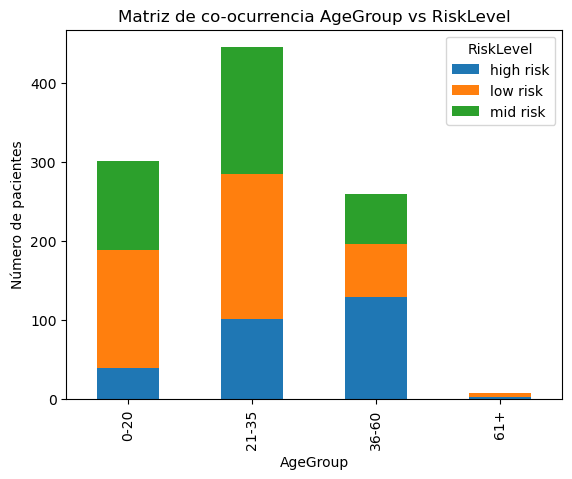

In [85]:
matriz = pd.crosstab(archivo['Age Group'], archivo['RiskLevel'])

print(matriz)

matriz.plot(kind='bar', stacked=True)
plt.title("Matriz de co-ocurrencia AgeGroup vs RiskLevel")
plt.xlabel("AgeGroup")
plt.ylabel("Número de pacientes")
plt.show()

## Resumen por grupos

In [86]:
resumen = archivo.groupby(['Age Group', 'RiskLevel'])[["PulsePressure", "MAP"]].mean()

resumen["PulsePressure_mediana"] = archivo.groupby(["Age Group", "RiskLevel"])["PulsePressure"].median()
resumen["MAP_mediana"] = archivo.groupby(["Age Group", "RiskLevel"])["MAP"].median()

print(resumen)

                     PulsePressure         MAP  PulsePressure_mediana  \
Age Group RiskLevel                                                     
0-20      high risk      28.717949   75.982906                   27.0   
          low risk       32.566667   78.155556                   30.0   
          mid risk       35.160714   83.166667                   40.0   
21-35     high risk      40.455446   98.881188                   40.0   
          low risk       33.635870   85.771739                   30.0   
          mid risk       41.875000   86.958333                   40.0   
36-60     high risk      40.968992  104.082687                   40.0   
          low risk       34.462687   90.368159                   40.0   
          mid risk       38.125000   94.895833                   35.0   
61+       high risk      50.000000  103.333333                   50.0   
          low risk       30.000000   80.000000                   30.0   
          mid risk             NaN         NaN     

## 3 grupos con mayor media 

In [87]:
mayor_pulso = resumen["PulsePressure"].sort_values(ascending=False).head(3)

print("Los 3 grupos con mayor presión de pulso son:")
print(mayor_pulso)

Los 3 grupos con mayor presión de pulso son:
Age Group  RiskLevel
61+        high risk    50.000000
21-35      mid risk     41.875000
36-60      high risk    40.968992
Name: PulsePressure, dtype: float64


In [88]:
mayor_MAP = resumen["MAP"].sort_values(ascending=False).head(3)

print("Los 3 grupos con mayor MAP son:")
print(mayor_MAP)

Los 3 grupos con mayor MAP son:
Age Group  RiskLevel
36-60      high risk    104.082687
61+        high risk    103.333333
21-35      high risk     98.881188
Name: MAP, dtype: float64


## Porcentaje de pacientes

In [89]:
arch_ordenado = archivo["PulsePressure"].sort_values(ascending=False)
n = len(arch_ordenado)
percentil_10 = arch_ordenado.iloc[int(0.1 * n)]

for grupo in mayor_pulso.index:

    grupo_datos = archivo[(archivo["Age Group"] == grupo[0]) & (archivo["RiskLevel"] == grupo[1])]

    total_pacientes = len(grupo_datos)

    pacientes_pulso_alto = len(grupo_datos[grupo_datos["PulsePressure"] >= percentil_10])

    pacientes_BS_alto = len(grupo_datos[grupo_datos["BS"] > 10])

    print("\nGrupo:" , grupo)

    print("Porcentaje PulsePressure en top 10", (pacientes_pulso_alto / total_pacientes)* 100)

    print("Porcentaje BS > 10:", (pacientes_BS_alto / total_pacientes)* 100)


Grupo: ('61+', 'high risk')
Porcentaje PulsePressure en top 10 0.0
Porcentaje BS > 10: 100.0

Grupo: ('21-35', 'mid risk')
Porcentaje PulsePressure en top 10 37.5
Porcentaje BS > 10: 0.0

Grupo: ('36-60', 'high risk')
Porcentaje PulsePressure en top 10 11.627906976744185
Porcentaje BS > 10: 89.14728682170544


<a id="T6"></a>
##  Tarea 6. Primeros modelos con scikit-learn. <a href="#index"><i class="fa fa-list-alt" aria-hidden="true"></i></a>
1. Dos versiones de los datos
   - Construye dos matrices de entrada:
     - ```X_base```: solo con los atributos originales.
     - ```X_ext```: con los atributos originales y los atributos numéricos derivados creados en la tarea anterior.
   - La etiqueta será ```y = RiskLevel```.
1. Train/test (misma partición)
   - Realiza una única partición entrenamiento/test (por ejemplo 70/30) manteniendo la proporción de clases.
   - Usa exactamente la misma partición para X_base y X_ext (mismas instancias en train y en test en ambos casos).
1. Modelos
   - Entrena tres clasificadores con métodos distintos  y evalúalos en test.
   - Repite la evaluación con ```X_base``` y con ```X_ext```.
1. Resultados
   - Presenta una tabla con accuracy y f1_macro en test para:
     - cada modelo con ```X_base```
     - cada modelo con ```X_ext```.

## Dos versiones de los datos

In [92]:
y = archivo["RiskLevel"]

X_base = pd.read_csv("Maternal Health Risk Data Set.csv")

X_ext = X_base.copy()
X_ext["PulsePressure_top10"] = (archivo["PulsePressure"] >= percentil_10).astype(int)
X_ext["BS_alto"] = (archivo["BS"] > 10).astype(int)

## Train / Test

In [91]:
from sklearn.model_selection import train_test_split

X_train_base, X_test_base, y_train, y_test = train_test_split(X_base, y, test_size=0.3, stratify=y, random_state=42)

X_train_ext = X_ext.loc[X_train_base.index]
X_test_ext = X_ext.loc[X_test_base.index]

## Modelos

In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

resultados = {"Modelo": [], "Dataset": [], "Accuracy": [], "F1_macro": []}

modelos = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "KNeighbors": KNeighborsClassifier()
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train_base, y_train)
    y_pred = modelo.predict(X_test_base)
    resultados["Modelo"].append(nombre)
    resultados["Dataset"].append("Base")
    resultados["Accuracy"].append(accuracy_score(y_test, y_pred))
    resultados["F1_macro"].append(f1_score(y_test, y_pred, average="macro"))
    
    modelo.fit(X_train_ext, y_train)
    y_pred = modelo.predict(X_test_ext)
    resultados["Modelo"].append(nombre)
    resultados["Dataset"].append("Extendido")
    resultados["Accuracy"].append(accuracy_score(y_test, y_pred))
    resultados["F1_macro"].append(f1_score(y_test, y_pred, average="macro"))

ValueError: could not convert string to float: 'mid risk'

## Resultados

<a id="T7"></a>
##  Tarea 7. Uso de atributos calculados. <a href="#index"><i class="fa fa-list-alt" aria-hidden="true"></i></a>
1. Árboles.
   - Crea árboles para ```X_base``` y ```X_ext```, limitando su tamaño.
   - Dibuja los árboles con los nombres de los atributos.
   - Comprueba si aparecen los atributos derivados en el árbol para ```X_ext```. Si no aparece, comprueba con árboles más grandes.
2. Importancia de atributos.
   - Para el árbol (y/o para algún otro modelo si lo prefieres), muestra el ranking de atributos por su importancia en el modelo.
   - ¿Aparecen los atributos calculados?
4. Comprobación de uso: permutación de calculados.
   - Para modelos ya entrenados con ```X_ext```, crea una copia del conjunto de test.
   - En esa copia del conjunto de test, permuta aleatoriamente los atributos derivados, de uno en uno. El resto del conjunto de test se mantiene igual.
   - Vuelve a calcular ```f1_macro```. Muestra sus valores y las diferencias con los valores antes de permutar.

<a id="T8"></a>
##  Tarea 8. Validación cruzada. <a href="#index"><i class="fa fa-list-alt" aria-hidden="true"></i></a>
1. Validación cruzada (k=5).
   - Evalúa los mismos 3 modelos con validación cruzada estratificada con 5 *folds*, tanto con ```X_base``` como con ```X_ext```.
   - Para cada combinación (modelo, versión de X) muestra la media y desviación de ```f1_macro```.
2. Matriz de confusión en CV.
   - Para cada modelo y cada versión de ```X```, obtén predicciones de validación cruzada para todas las instancias y construye la matriz de confusión correspondiente.
   - Muestra las 6 matrices (3 modelos * 2 versiones).
   - Indica en qué clases se confunden más y si cambia al pasar de ```X_base``` a ```X_ext```.
3. Selección.
   - ¿Con qué modelo y versión de ```X``` te quedarías?

<a id="T9"></a>
##  Tarea 9. Efecto de los duplicados. <a href="#index"><i class="fa fa-list-alt" aria-hidden="true"></i></a>
1. Validación cruzada sin coincidencias en train y test.
   - Para uno de los modelos usados en el apartado anterior, repite la validación cruzada estratificada (k=5), pero en cada fold elimina del conjunto de entrenamiento todas las instancias cuyos valores de entrada (atributos) coincidan exactamente con los de alguna instancia del conjunto de test de ese fold (aunque la etiqueta sea distinta).
2. Comparación.
   - Compara el rendimiento obtenido con y sin esta eliminación (al menos f1_macro, media y desviación). Indica si el cambio es apreciable.
   - Compara también la matriz de confusión agregada.

<a id="T10"></a>
##  Tarea 10. Análisis libre. <a href="#index"><i class="fa fa-list-alt" aria-hidden="true"></i></a>

Realiza un pequeño análisis de tu elección con el dataset (puede ser exploratorio con Pandas, predictivo con scikit-learn, o una combinación). No se espera un trabajo extenso, debe ser comparable en tamaño al resto de tareas.
1. Plantea en una o dos frases la pregunta u objetivo.
2. Incluye al menos:
   - una operación de Pandas.
   - una evaluación de un modelo de scikit-learn
   - una visualización.
3. Termina con una conclusión breve, basada en los resultados obtenidos.
